# 1. 이번 과정의 목표
- 이번 챕터 주제는 신경망입니다.
- 신경망, 딥러닝 라이브러리인 Pytorch 라이브러리를 사용할겁니다.
  - 1. PyTorch를 소개하고
  - 2. 신경망(Neural Network, NN)을 다룹니다.
  - 3. 신경망으로 선형회귀, 로지스틱회귀를 만들어봅니다.
  - 4. 신경망으로 숫자 분류기를 만들어봅니다. (MNIST 데이터셋 사용)

# 2. PyTorch 소개
- Deep Learning을 쉽게 구현하도록 만들어진 오픈소스 Library 입니다.
  - 예전에는 텐서플로우(구글개발)이 딥러닝 Library의 왕이 었습니다.
    - C++로 만들어졌고, 성능도 빨라요.
    - 개발자가 쓰기엔 괜찮은데, AI연구자가 쓰기엔 코딩 지식이 많이 필요해서 쓰기 힘들어요.
  - 그리고 PyTorch(메타 개발)와 같은 다양한 딥러닝 라이브러리가 나왔습니다.
    - AI연구자들 사이에서 PyTorch 인기가 폭발했습니다.
    - 새로운 기능은 항상 텐서플로우가 먼저 개발되고, PyTorch가 조금 더 있다가 출시되었죠.
    - 당시 AI연구자들 사이에서도 텐서플로우 할줄알면 "올~ 쫌 하네?" 라는 분위기 였습니다
  - 현재는 PyTorch 인기가 텐서플로우 인기를 앞섰습니다.
    - 이제는 PyTorch나 텐서플로우나 새로운 기능은 거의 동시에 출시됩니다.
    - PyTorch는 텐서플로우보다 파이써닉합니다. (간결합니다.)
    
  - 텐서플로우는 아직도 많이 쓰입니다.
    - AI 연구자에게 인기는 적어졌지만, 디테일한 옵션과 최적화를 해야하는 극단적인 세팅이 필요한 환경에서는 여전히 쓰입니다.
    - '왕'의 자리는 PyTorch에게 물려줬지만, 초 대규모 모델 개발시 or 초 소형 모델 개발시(임베디드 환경)에는 아직 필요합니다.



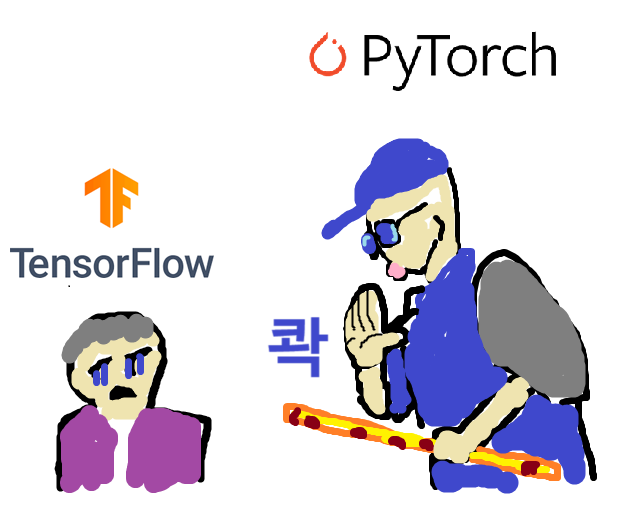

# 3. PyTorch 기본 사용법
- Numpy Array 대신 PyTorch 텐서(Tensor)를 사용합니다.
  - PyTorch Library에서는 벡터를 1차원 텐서라고 합니다.
  - PyTorch Library에서는 행렬을 2차원 텐서라고 합니다.
  - PyTorch Library에서는 행렬들이 N 개있으면 을 3차원 텐서라고 합니다.
  - PyTorch Library에서는 3차원 텐서가 N개 있으면 4차원 텐서라고 합니다.


In [117]:
import torch

a = torch.tensor([1, 2, 3]) # 1차원 텐서 (벡터)

b = torch.tensor([[1, 2, 3], [4, 5, 6]]) # 2차원 텐서 (행렬)

print(a)
print()
print(b)

tensor([1, 2, 3])

tensor([[1, 2, 3],
        [4, 5, 6]])


### Numpy Array와 Tensor 차이
- Numpy array는 CPU 로 계산을 합니다. Tensor는 CPU 뿐만 아니라 GPU로도 계산을 할 수 있습니다.
- PyTorch로 딥러닝 할때는 Numpy 대신 Tensor를 쓰면 됩니다.
  - Numpy와 문법이 거의 똑같습니다.

- 아래 3개의 샘플코드를 이해해주세요.


In [118]:
import numpy as np
import torch

# NumPy
a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6], [7, 8]])
print((a + b) @ b) # 행렬 합과 곱
print()

# PyTorch
a = torch.tensor([[1, 2], [3, 4]])
b = torch.tensor([[5, 6], [7, 8]])
print((a + b) @ b) # 행렬 합과 곱

[[ 86 100]
 [134 156]]

tensor([[ 86, 100],
        [134, 156]])


In [119]:
import numpy as np
import torch

# NumPy
a = np.array([[1, 2], [3, 4]])
print(a ** 2) # 제곱
print(np.sum(a)) # 전체 합
print()

# PyTorch
a = torch.tensor([[1, 2], [3, 4]])
print(a ** 2) # 제곱
print(torch.sum(a)) # 전체 합

[[ 1  4]
 [ 9 16]]
10

tensor([[ 1,  4],
        [ 9, 16]])
tensor(10)


In [120]:
import torch

# MSE
def loss(y_hat : torch.Tensor, y : torch.Tensor) :
  return torch.mean((y_hat - y) ** 2)

# 예측값과 실제값
y_hat = torch.tensor([2.5, 0.0, 2.1, 7.8])
y = torch.tensor([3.0, -0.5, 2.0, 7.0])

# MSE 출력
print(loss(y_hat, y))

tensor(0.2875)


### 그럼 Tensor만 쓰면 되고, Numpy 안써도 되는거 아니에요?
- PyTorch로 신경망, 딥러닝 모델 다룰때는 Numpy 안써도 됩니다. Tensor로 다 됩니다.
  - matplotlib은 Numpy와 PyTorch의 Tensor 모두 지원합니다.
  - LLM Library 들은 Numpy 보다는 PyTorch의 Tensor를 더 선호합니다.
- 그런데 아래 Library에서는 PyTorch의 Tensor가 아닌 Numpy를 지원합니다.
  - OpenCV : 이미지 전처리, 영상처리의 AI의 왕
  - Scikit-learn : 머신러닝의 왕

<br/>

- 그래서 AI를 배울때는 Numpy랑 PyTorch의 Tensor 모두 배워야합니다.
- PyTorch의 Tensor나 Numpy나 사용방법이 똑같아서, 둘다 배우는데 무리는 없습니다.

# 4. PyTorch의 자동 미분 기능 - Autograd (Automatic Gradient)
- Gradient : 미분값(기울기) 입니다.
  - 사람이 수학식을 코딩할 필요 없이, 함수 호출로 미분결과를 빠르게 얻을 수 있습니다.
- 학습을 할때(GD할때) 미분을 계속 하잖아요? **미분을 빨리할 수 있다면 학습 속도가 올라갑니다!.**
  - 그래서 AI에서 자동 미분 기능은 정말 중요한 기능이라고 할 수 있습니다.
- Tensor 내부적으로.. 엄청 빠른 미분계산을 위해, 내부 세팅이 필요합니다.

- PyTorch에서는 `requires_grad=True`로 옵션이 설정된 텐서에 대해, 그 텐서로부터 시작된 이후의 모든 연산을 자동으로 추적(기억)합니다. 즉, 연산 과정 정체를 다 기록합니다.

- 예를들면 `x=(3x)^2` 식에 미분을 한 다음 x에 2를 대입한 결과를 확인한다고 가정해 보겠습니다.


In [121]:
x = torch.tensor(2.0, requires_grad=True)
y = x * 3
z = y ** 2
z.backward()
print(x.grad) # x가 2일때의 기울기 (미분값)출력

tensor(36.)


위와 같은 코드가 있다고 가정하겠습니다. <br>
`requires_grad=True` 옵션을 넣으면 해당 옵션에서 부터 Pytorch가 계산과정 전체를 다 기억한다음 <br>`backward()`로 미분을 요청하면 Pytorch가 뒤에부터 연산과정을 거꾸로 올라가면서
변수 x에 대한 기울기를 자동계산을 해 줍니다.

In [122]:
import torch

x = torch.tensor(2.0, requires_grad=True) #requires_grad=True 중요!

y = x * 3
#y.retain_grad()  # y기울기 출력을 위한 함수
                  # Pytorch는 연산의 과정 중에는 기울기를 따로 저장하지 않아서 retain_grad()함수 사용해야 출력가능
z = y ** 2
#z.retain_grad()

z.backward()      # 거꾸로 강을 거슬러 오르는 저 힘찬 연어들처럼 미분해줘!!

print("z.grad:", z.grad) # 1. z를 z로 미분해서 1출력
print("y.grad:", y.grad) # 2. z=y^2(제곱) 이니까 y.grad=1*2y
print("x.grad:", x.grad) # 3. z를 y=3x 이니까 x.grad=12*3





z.grad: None
y.grad: None
x.grad: tensor(36.)


/tmp/ipykernel_55/3779948012.py:13: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:489.)
  print("z.grad:", z.grad) # 1. z를 z로 미분해서 1출력
/tmp/ipykernel_55/3779948012.py:14: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See gi

- 결과적으로 나중에는 x가 2일때의 기울기(x.grad)에 학습률(lr)을 곱한 만큼,
  - x는 기울기 반대방향으로 업데이트 되고
  - 그 결과 출력값 z(손실정도)가 변합니다.
  - 즉, 얼만큼 업데이트 할지는 학습률이 영향을 끼치고
  - 어떻게 업데이트를 할지는 optimizer에 따라 차이가 날 수 있습니다.

- 하나더 체크해야 할 점은 `.backward()`를 호출하면, 그동안 계산된 기울기가(미분값) 이전 기울기 값에 계속 더해집니다.
  - 새로 구한 Gradient로 덮어쓰지 않고 누적(add)이 되는 방식입니다. 예를들면

In [123]:
import torch

x = torch.tensor(2.0, requires_grad=True)

for i in range(3):

    y = x * 3
    z = y ** 2

    z.backward()

    print(f"{i+1}번째:", x.grad)

    x.grad.zero_() #미분값 초기화


1번째: tensor(36.)
2번째: tensor(36.)
3번째: tensor(36.)


- `backward`통해서 미분해줘!’라고 하면, 그동안의 누적된 연산이 미분값을 순식간에 뱉어 냅니다.

- 이제 미분이 필요할 때가 되면, .backward()를 딱 한 번 호출하기만 하면 됩니다.
그 순간 PyTorch가 역전파를 수행해서, 각 파라미터의 Gradient를 순식간에 계산해 줍니다.

- `requires_grad=True`미분 추적 기능을 ON / OFF 할 수 있습니다.
  - **미분 추적 기능** 을 ON 하면, 연산 과정이 모두 기록되어 자동 미분이 가능하지만 그만큼 메모리와 연산 비용이 늘어납니다.
  - **미분 추적 기능** 은 불필요할 때는 OFF 해줘야, 메모리나 계산속도 저하가 없습니다.

In [124]:
x = torch.tensor(2.0, requires_grad=True) # requires_grad=True <-- 미분 추적 기능 ON !
y = x**2 + 3*x + 1 # <--- 이거 연산할 때, 빠른 미분을 위한 계산과정을 pytorch가 기억해두고

y.backward()   # 미리 기억해 놓은 계산 이용해 빠른게 미분을 수행
print(x.grad)  # 결과 확인 (미분값 출력)


# 미분 추적 기능 OFF(with 절 내에서만)
with torch.no_grad():      # with 문 내부 코드는, 추적 기능 OFF 된 상태로 동작됩니다.
  y = x ** 2 + 5*x + 10    # <--- 이때는 빠른 미분을 위한 내부연산을 안함
  #y.backward()            # 에러 발생


# 다시 여기서 부터는 미분 추적 기능이 ON 됩니다.(with문 밖에서는 ON)
y = x ** 2 + 4*x + 1
y.backward()
print(x.grad)  # 기울기 값은 자동 누적

# 기울기 누적 초기화
x.grad.zero_()
y = x ** 2 + 4*x + 1
y.backward()
print(x.grad)  # 기울기 값은 자동 누적

tensor(7.)
tensor(15.)
tensor(8.)


### 미분 추적 기능은.. 언제 ON 하고, 언제 OFF 하나요?
- ON 할 때
  - 학습할 때 부터 ON 하면 됩니다.
  
- OFF 할 때
  - 중간평가(Validation) 할 때나 최종평가 (Test) 할 때는 OFF 하면 됩니다.
  - 시각화 할 때 OFF 하면 됩니다.

### 결론
- PyTorch의 Tensor는 Numpy처럼 연산이 가능합니다.
- Numpy에는 없지만 Tensor에 있는 기능은 다음과 같습니다
  - 빠른 미분 계산 기능을 지원합니다. 빠른 미분 계산은 AI 학습에서 엄청 중요하죠.
  - GPU 연산도 지원합니다. 이 기능은 이번 챕터가 아닌 다른 챕터에서 설명드릴겁니다.

# 5. nn.Linear의 이해
- 신경망으로 넘어오겠습니다.
- 신경망의 기본 수식은 y = ax + b 입니다. 선형함수라고 하고 PyTorch에서는 nn.Linear()로 표현합니다.
- 그 동안 y = ax + b 라고 했는데, 신경망 이론에서는 기울기와 절편이 아닌 다른 용어를 씁니다.
  - 수학에서는 기울기(a)와 절편(b)이라는 말을 쓰지만, 딥러닝에서는 Weight와 Bias 라는 말을 사용합니다.
  - 의미는 같고 용어만 바뀐겁니다. 앞으로 Weight와 Bias 라고 하겠습니다.

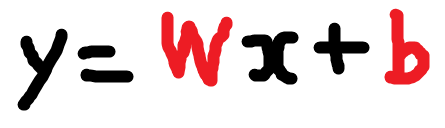

### 선형함수의 입력과 출력의 개수
- tips 데이터셋 기억나시죠?
  - 입력 : total_bill(결제금액)
  - 출력 : tip(받은 팁)
- 여기서 입력과 출력의 개수는 각각 1개, 1개입니다.
- 입력 데이터가 여러개 일수도 있습니다.
  - 입력 1 : 결제금액
  - 입력 2 : 사람 연령대
  - 출력 : 받은 팁
- 위와 같은 입력1, 2에 따른 팁을 추정할 수 있는 모델이 되겠습니다.
- 수식으로 표현하면 다음과 같습니다.

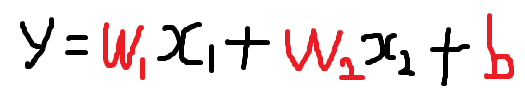

- 그러니까 MSE가 최소가 나오는 w1, w2, b 를 찾아야 하는것이죠.
- 행렬식으로도 알고 있어야합니다. 아래와 같이 표현합니다.

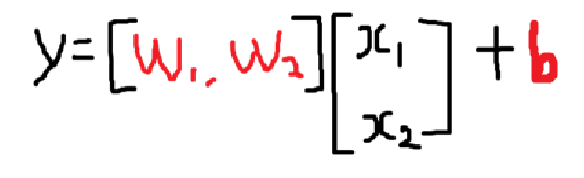

- 이를 기억해주세요.
  - **입력 값 개수에 따라, 학습이 필요한 weight의 개수가 늘어납니다.**

- 입력 데이터 뿐만 아니라 출력 데이터도 여러개 일 수 있습니다.
- 입력 1, 출력 2 예시입니다.
  - 입력 : 결제금액
  - 출력 : 받은 팁
  - 출력 : 웨이터를 호출한 횟수


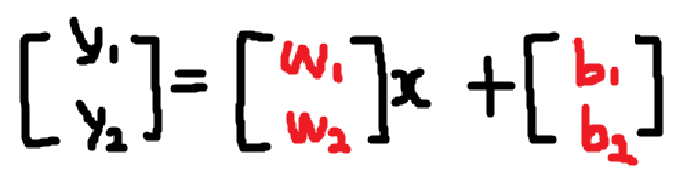

- 이를 기억해주세요.
  - **출력 값의 개수에 따라, 학습에 필요한 w, b 세트 개수가 늘어납니다.**

- 이번엔 입력 3개, 출력 2개 예시입니다.
  - 하나의 입력당 weight가 3개 필요합니다.
  - 하나의 출력당, weight와 bias가 2세트 필요합니다.

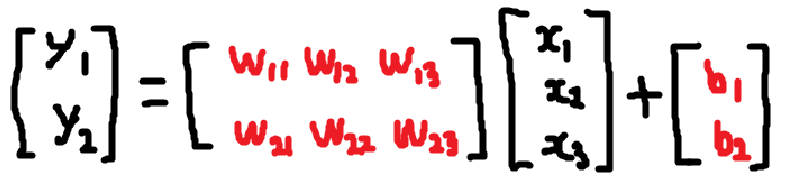

- 입력과 출력 값의 개수에 따라, 학습할 파라미터 개수가 많아지면, 학습 속도가 느려질겁니다
  - GD 하는데, MSE가 작은 곳 까지 도달하는데 한참 걸릴겁니다.
  - 하지만,  아무리 입력·출력 차원이 커지고 파라미터 수가 많아져도, 기본적인 모델의 형태는 변하지 않습니다.
  - **y = Wx + b 의 형태를 유지하는 건 변함이 없습니다.**

- 다시 돌아와서...
- 입력데이터 1개, 출력 데이터 1개 일 때 실습을 해보겠습니다.
- tips 데이터로 선형회귀를 만들어보죠.
- 아래 코드를 모두 이해해야 합니다!

Epoch    0 | Loss: 288.7673
Epoch  400 | Loss: 1.5177
Epoch  800 | Loss: 1.4044
Epoch 1200 | Loss: 1.3178
Epoch 1600 | Loss: 1.2516

[학습완료]
학습된 가중치(weight): 0.14673182368278503
학습된 편향(bias)) : -0.07097022980451584




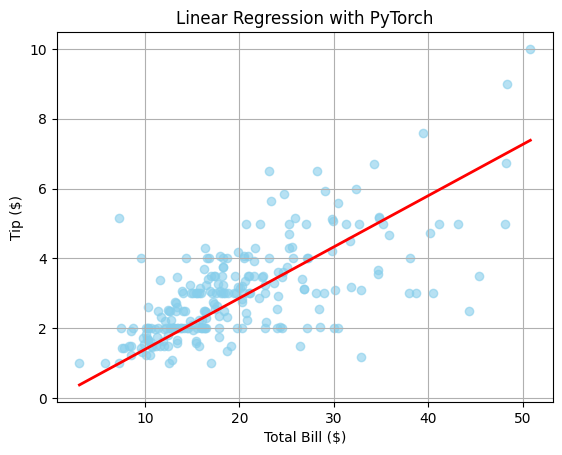

In [125]:
import torch
import torch.nn as nn #선형모델 불러오기
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 준비 (Seaborn의 tips 데이터셋)
tips = sns.load_dataset("tips")

# 입력(X): total_bill, 출력(y): tip
# 아래 dtype은 데이터 타입을 float 으로 저장하라는 뜻입니다
# nn.Linear 모델은 행렬을 입력과 출력으로 받습니다. -> 백터는 reshape 해야함, 딥러닝에서 float는 32비트 사용이 최적화 되어있음
X = torch.tensor(tips["total_bill"].values, dtype=torch.float32).reshape(-1, 1)
y = torch.tensor(tips["tip"].values, dtype=torch.float32).reshape(-1, 1)

# 모델 정의 - 선형함수 y = wx + b 하나 생성
model = nn.Linear(1, 1)  # 입력 1개(total_bill), 출력 1개(tip)

# 손실함수 & 옵티마이저(최적화)
# 옵티마이저 = weight, bias를 변경하는 알고리즘 종류, GD를 사용합니다.
criterion = nn.MSELoss() # MSE 사용
optimizer = optim.SGD(model.parameters(), lr=0.001) #학습률0.001(경사하강법에서 점프를 어느정도로 뛸건지)

# 딥러닝 학습 루프 !중요!
for epoch in range(2000): # 점프 2000번~!

    optimizer.zero_grad() # 미분 계산 초기화

    y_hat = model(X) # 모델 예측

    loss = criterion(y_hat, y) # 로스 계산

    loss.backward() # 미분 계산 수행 (미분 추적 기능 ON?) 

    optimizer.step() # GD 점프 1회 (w, b 값이 업데이트 됩니다.)

    if epoch % 400 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.4f}") #4d = 자릿수 확보, 4f=소수점 4자리



# 학습 결과 출력
print()
print('[학습완료]')
print(f'학습된 가중치(weight): {model.weight.item()}') # .item() 텐서에서 값 1개 출력(텐서 출력 메소드) / tolist() : 텐서 값 여러개 출력
print(f'학습된 편향(bias)) : {model.bias.item()}')
print()

# 예측 선 준비 (학습하는 것이 아니므로 미분 추적 기능 OFF)
with torch.no_grad():
  x_line = torch.linspace(X.min(), X.max(), 100).reshape(-1, 1) #(with torch.no_grad()로 쓸데없이 미리 계산 기억하는거 방지)
  y_line = model(x_line)

  # 시각화
  plt.scatter(X.numpy(), y.numpy(), color='skyblue', alpha=0.6)
  plt.plot(x_line.numpy(), y_line.numpy(), color='red', linewidth=2)
  plt.title("Linear Regression with PyTorch")
  plt.xlabel("Total Bill ($)")
  plt.ylabel("Tip ($)")
  plt.grid(True)
  print()

### 위 소스코드에서 미분 추적기능 ON 안했는데, 미분이 되네요?!
- model = nn.Linear(1, 1) 코드를 실행하면 내부적으로 2개의 파라미터가 생성됩니다.
  - model.weight 텐서
  - model.bias 텐서
- 그리고 위 Tensor 값은 requires_grad = True 옵션으로 생성됩니다.
- **결론적으로 nn.Linear() 함수 수행부터 '미분 추적 기능'이 ON 됩니다.**


# 6. 함수 중첩과 Sequential Model
- 수학적으로 함수 중첩이라는 말을 먼저 살펴보겠습니다.


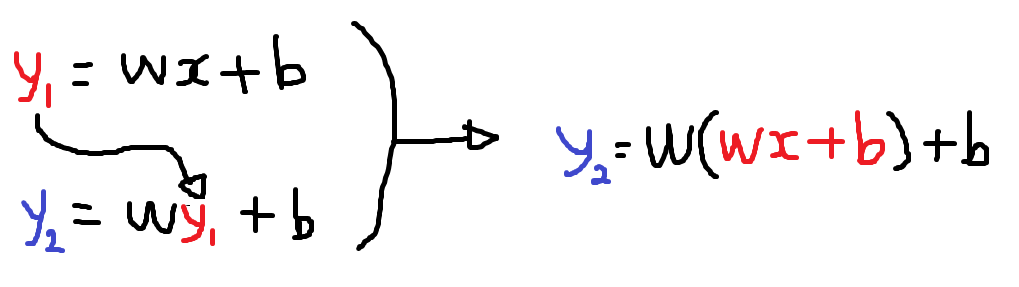

- 수학에서는 한 함수의 결괏값이 다른 함수의 입력값으로 들어오는 것을 함수 중첩이라고 합니다.
- 신경망에서는 "함수 중첩"이라는 용어를 안쓰고, Sequential(순차적) Model 구조라고 합니다.

### Sequencial Model 언제 쓰죠?
- 우리 썼었어요~. 로지스틱 회귀할 때 사용했습니다.
  - y = sigmoid(ax + b) 기억나시죠?
- PyTorch 에서는 이 Sequencial Model 을 만들기 위한 간결한 문법을 지원합니다.
  - ```
    model = nn.Sequential(
    nn.Linear(입력특성개수, 출력특성개수),
    nn.Sigmoid()
)```


### 공부시간별 합격 확률을 구하는 로지스틱 회귀 예시를 PyTorch로 만들어보겠습니다.

Epoch   0 | Loss: 0.6659
Epoch 100 | Loss: 0.3477
Epoch 200 | Loss: 0.2817
Epoch 300 | Loss: 0.2409
Epoch 400 | Loss: 0.2131
학습완료



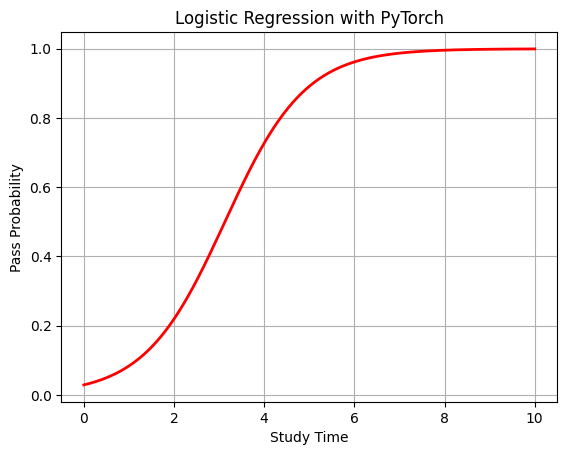

In [126]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 공부 시간
X = torch.tensor([
    [1.0], [2.0], [3.0], [4.0], [5.0], [6.0],
    [2.0], [3.0], [4.0], [5.0], [6.0], [7.0],
    [1.0], [2.0], [3.0], [4.0], [5.0], [6.0],
    [7.0], [8.0], [2.0], [3.0], [4.0], [5.0],
    [6.0], [7.0], [8.0], [9.0], [10.0]
])

# 합격 여부 (0 : 불합격, 1 : 합격)
y = torch.tensor([
    [0.0], [0.0], [0.0], [1.0], [1.0], [1.0],
    [0.0], [0.0], [1.0], [1.0], [1.0], [1.0],
    [0.0], [0.0], [0.0], [1.0], [1.0], [1.0],
    [1.0], [1.0], [0.0], [0.0], [1.0], [1.0],
    [1.0], [1.0], [1.0], [1.0], [1.0]
])

# [중요] 아래 모델은 sigmoid(wx + b) 가 됩니다.
model = nn.Sequential(
    nn.Linear(1, 1),
    nn.Sigmoid()
)

criterion = nn.BCELoss() # Binary 크로스 엔트로피 손실 함수(이진분류때 사용하는 손실함수)
optimizer = optim.SGD(model.parameters(), lr=0.1) # GD 사용

for epoch in range(500):

    optimizer.zero_grad() # 초기화

    y_hat = model(X)

    loss = criterion(y_hat, y)

    loss.backward() # 미분 계산

    optimizer.step() # 학습 (w, b 값 업데이트)

    if epoch % 100 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f}")

print('학습완료')

# 예측 선 준비
with torch.no_grad():
  x_line = torch.linspace(0, 10, 200).reshape(-1, 1)
  y_line = model(x_line)

  # 시각화
  plt.plot(x_line.numpy(), y_line.numpy(), color='red', linewidth=2)
  plt.title("Logistic Regression with PyTorch")
  plt.xlabel("Study Time")
  plt.ylabel("Pass Probability")
  plt.grid(True)
  print()

# 7. 함수의 중첩과 활성화 함수로 비선형 구현하기


- y = wx + b와 같은 구조로는 치킨 라인, 고양이 곡선 처럼 비선형을 표현할 수 없었습니다.
  - y = w(w(wx + b) + b) + b .. 와 같이 함수 중첩으로도 비선형을 표현할 수 없었습니다.
- 그런데 활성화 함수와 함수 중첩을 함께 사용하니까, 모든 비선형 곡선을 표현할 수 있습니다.
  - 수학적 원리는 EASY 교안에서 다루지 않습니다.
  - 수학적 원리는 교수님이 설명해주실겁니다. ^^


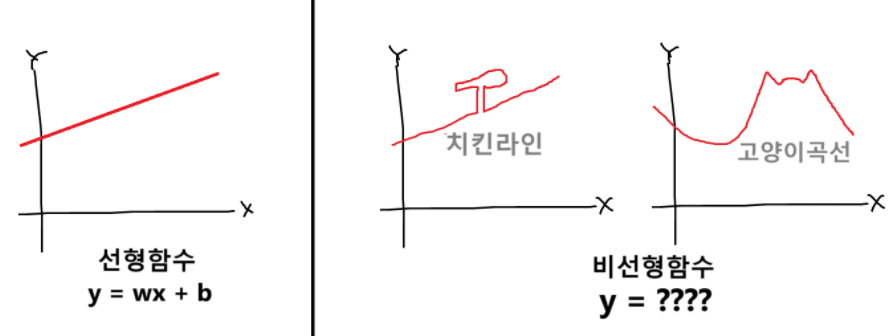

- 우리는 결과만 이해하도록 하겠습니다.
- 활성화 함수는 대표적으로 ReLU (렐루라고 읽습니다. 할렐루야 할때 렐루입니다.) 가 있습니다.
- ReLU 는 단순합니다.
  - 음수는 모두 0으로 바꾼다.
  - 양수는 그대로 사용한다.
- ReLU 는 조건부 수식으로 표현합니다.

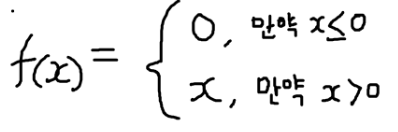

- ReLU 함수 자체는 비선형 방정식입니다.
  - 선형 방정식(y = ax + b로 표현될 수 있는 방정식)이 아닌건 다 비선형입니다.
- 수학자에 의해 **비선형 방정식의 중첩으로, 모든 비선형을 나타낼 수 있음**은 1980년대에 증명이 되었습니다.
  - 그리고 비선형 방정식 중에 특히 ReLU는 학습 속도에 되게 좋아요! 라고 제프리힌튼 교수님이 강조하고, 실 사용에 증명했습니다. (2010년)
  - 딥러닝이 실제로 학습될 수 있게 만든 핵심 열쇠 중 하나가 됨
- 고양이곡, 치킨곡선 같은 것도, 비선형 방정식 중첩으로 표현할 수 있습니다.
  - 제가 이름을 지은 곡선입니다.


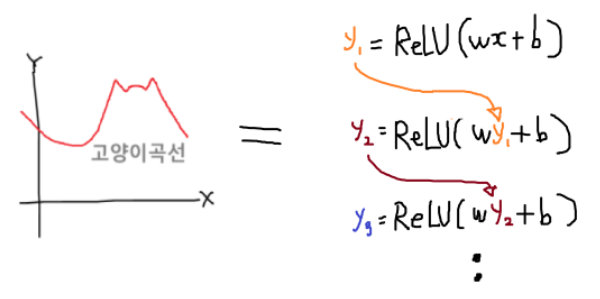

- 신경망 이론에서는 비선형 방정식의 각 단계를 'Layer' 라고 부르기로 했습니다.



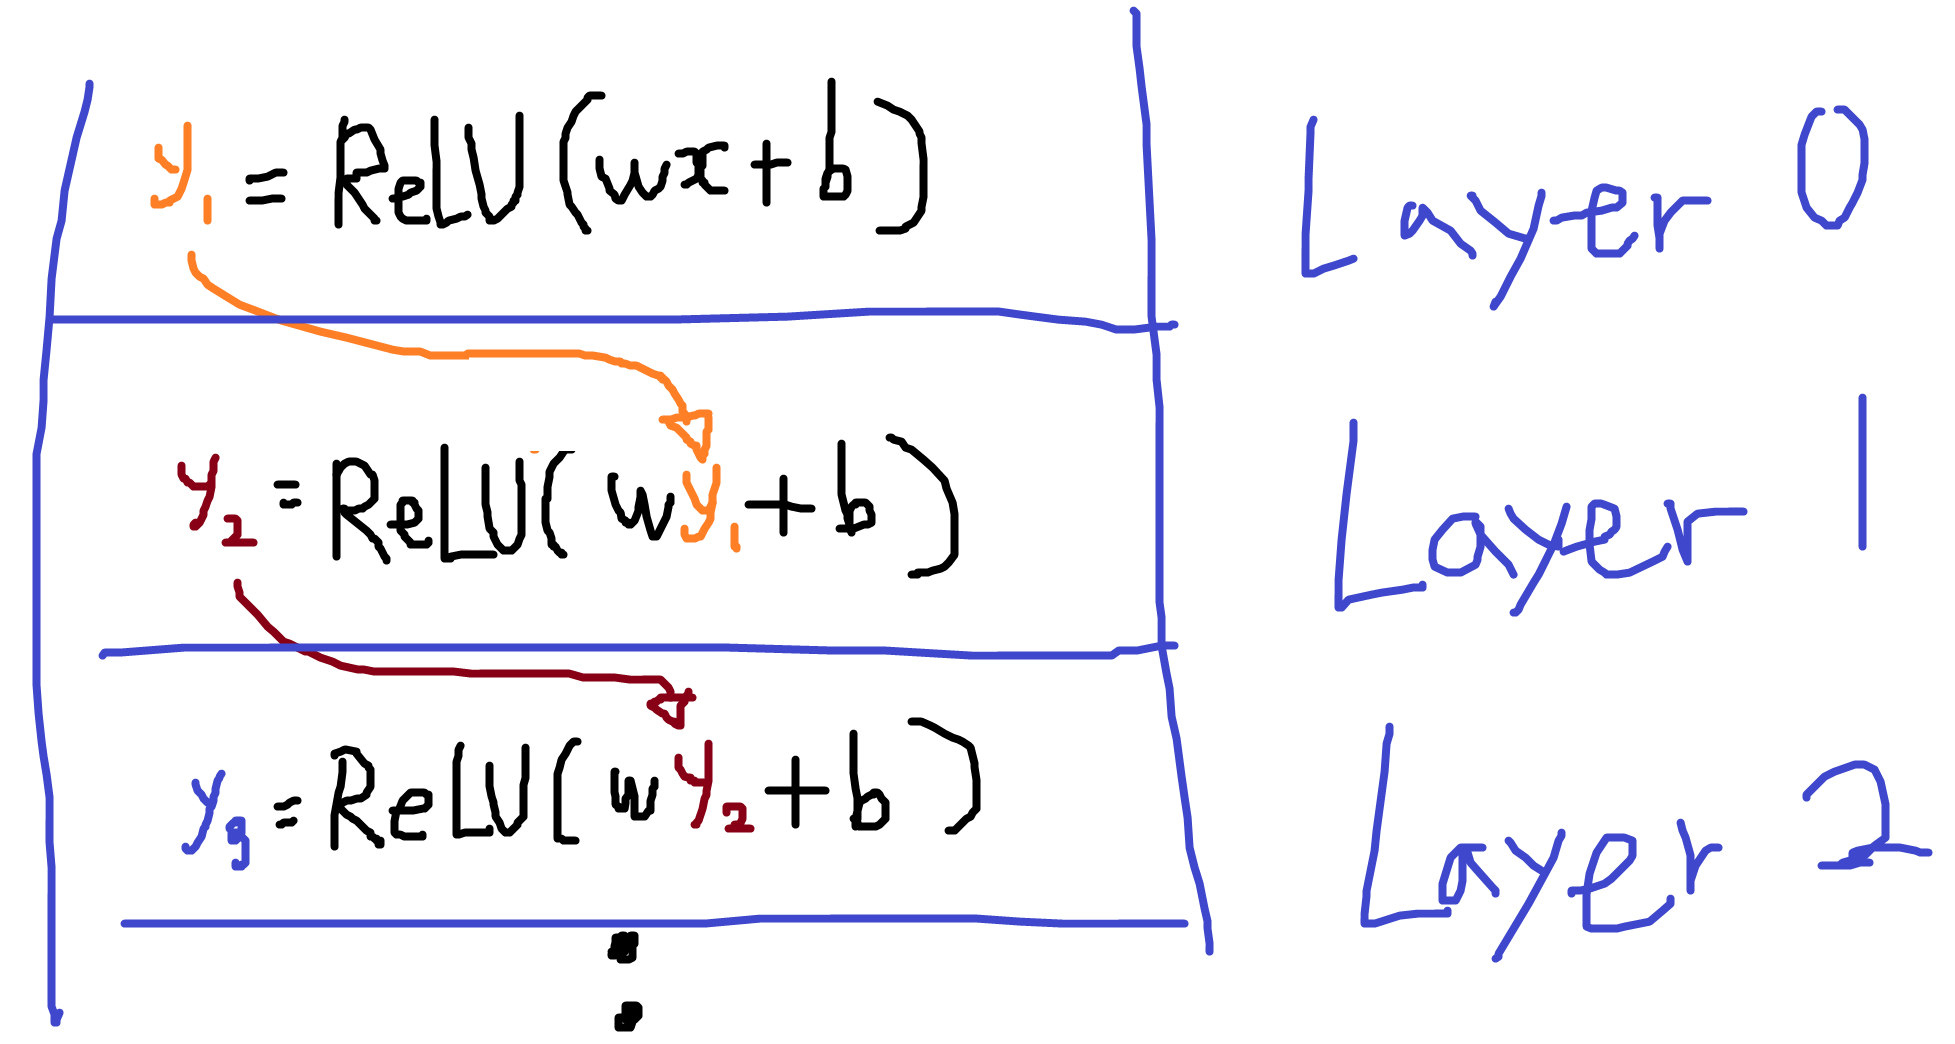

### [참고] 학습 결과 비선형 방정식이 만들어지는 예시

- 비선형 방정식의 중첩으로 고양이 곡선을 한번 만들어보겠습니다.
- 내부 코드는 눈으로만 가볍게 살펴봐주세요.
  - 레이어 입력과 출력 개수에 대한 설명은 나중에 하겠습니다.
  - 레이어 개수, 레이어의 입력과 출력 개수, lr, epoch 전부 하이퍼파라미터입니다.
    - 모양이 잘 나올때까지 막 찍었어요.

Epoch     0 | Loss: 39.820091
Epoch   500 | Loss: 0.043940
Epoch  1000 | Loss: 0.034990
Epoch  1500 | Loss: 0.017469
Epoch  2000 | Loss: 0.011156
Epoch  2500 | Loss: 0.007315
Epoch  3000 | Loss: 0.012222
Epoch  3500 | Loss: 0.023752
Epoch  4000 | Loss: 0.005257
Epoch  4500 | Loss: 0.005245
Epoch  5000 | Loss: 0.027549
Epoch  5500 | Loss: 0.016727
Epoch  6000 | Loss: 0.031929
Epoch  6500 | Loss: 0.029226
Epoch  7000 | Loss: 0.004455
Epoch  7500 | Loss: 0.001651
Epoch  8000 | Loss: 0.010083
Epoch  8500 | Loss: 0.001256
Epoch  9000 | Loss: 0.009970
Epoch  9500 | Loss: 0.001208



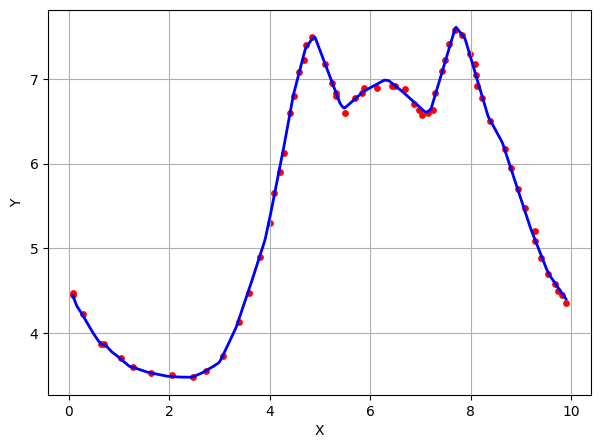

In [127]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 고양이 좌표
data = torch.tensor([
    [0.65, 3.87],[0.08, 4.47],[0.08, 4.45],[0.28, 4.22],[0.70, 3.87],
    [1.03, 3.70],[1.28, 3.60],[1.63, 3.53],[2.05, 3.50],[2.48, 3.48],
    [2.73, 3.55],[3.08, 3.73],[3.38, 4.13],[3.58, 4.47],[3.80, 4.90],
    [4.00, 5.30],[4.08, 5.65],[4.20, 5.90],[4.28, 6.13],[4.40, 6.60],
    [4.48, 6.80],[4.58, 7.08],[4.68, 7.22],[4.73, 7.40],[4.85, 7.50],
    [5.10, 7.18],[5.25, 6.95],[5.33, 6.83],[5.33, 6.80],[5.50, 6.60],
    [5.70, 6.78],[5.83, 6.83],[5.88, 6.90],[6.13, 6.90],[6.43, 6.92],
    [6.50, 6.92],[6.70, 6.88],[6.88, 6.70],[6.98, 6.63],[7.03, 6.57],
    [7.30, 6.83],[7.43, 7.10],[7.50, 7.22],[7.58, 7.42],[7.68, 7.58],
    [7.15, 6.60],[7.25, 6.63],[7.83, 7.52],[7.98, 7.30],[8.08, 7.18],
    [8.10, 7.05],[8.13, 6.92],[8.23, 6.78],[8.38, 6.50],[8.68, 6.17],
    [8.80, 5.95],[8.95, 5.70],[9.08, 5.47],[9.28, 5.20],[9.28, 5.08],
    [9.40, 4.88],[9.55, 4.70],[9.68, 4.58],[9.75, 4.50],[9.83, 4.45],
    [9.90, 4.35]
], dtype=torch.float32)

# 입력(X), 출력(y)
X = data[:, [0]]
y = data[:, [1]]

# 모델 정의 (비선형 MLP)
#ReLU함수에 의해 꺾이는 지점이 생겨서 선형 -> 비선형
model = nn.Sequential(
    nn.Linear(1, 64), # Layer 0, 입력은 1개, 출력은 64개
    nn.ReLU(),
    nn.Linear(64, 128), # Layer 1, 입력은 64개, 출력은 128개
    nn.ReLU(),
    nn.Linear(128, 128), # Layer 2, 입력은 128개, 출력 128개
    nn.ReLU(),
    nn.Linear(128, 1) # Layer 3, 최종 출력은 1개
)

# 손실함수 & 옵티마이저
criterion = nn.MSELoss()

#optimizer = optim.SGD(model.parameters(), lr=0.01) # GD
optimizer = optim.Adam(model.parameters(), lr=0.005) # 그냥 GD 보다 Adam 이 성능이 더 잘나와요.

# 학습 루프
for epoch in range(10000):
    y_pred = model(X)
    loss = criterion(y_pred, y)

    optimizer.zero_grad() #위치 상관 없음
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch:5d} | Loss: {loss.item():.6f}")

# 예측 곡선 생성
with torch.no_grad():
  x_line = torch.linspace(X.min(), X.max(), 400).reshape(-1, 1)
  y_line = model(x_line)

  # 시각화
  plt.figure(figsize=(7,5))
  plt.scatter(X.numpy(), y.numpy(), color='red', s=15)
  plt.plot(x_line.numpy(), y_line.numpy(), color='blue', linewidth=2)
  plt.xlabel("X")
  plt.ylabel("Y")
  plt.grid(True)
  print()


- 다음은 치킨 곡선입니다. (만들기 힘들었습니다.)
  - 치킨곡선의 특징은 한 x에 여러개 y가 존재하는 차트입니다.
  - 따라서 MLP로 표현할 수 없고 다음과 같이 그릴 수 있습니다.
    - 입력 : t 시간
    - 출력 : [x, y] 좌표

Epoch     0 | Loss: 24.481331
Epoch  1000 | Loss: 0.578540
Epoch  2000 | Loss: 0.256070
Epoch  3000 | Loss: 0.067232
Epoch  4000 | Loss: 0.036234
Epoch  5000 | Loss: 0.028970
Epoch  6000 | Loss: 0.023133
Epoch  7000 | Loss: 0.018570
Epoch  8000 | Loss: 0.014874
Epoch  9000 | Loss: 0.012522
Epoch 10000 | Loss: 0.011224
Epoch 11000 | Loss: 0.010473
Epoch 12000 | Loss: 0.010122
Epoch 13000 | Loss: 0.009856
Epoch 14000 | Loss: 0.009684



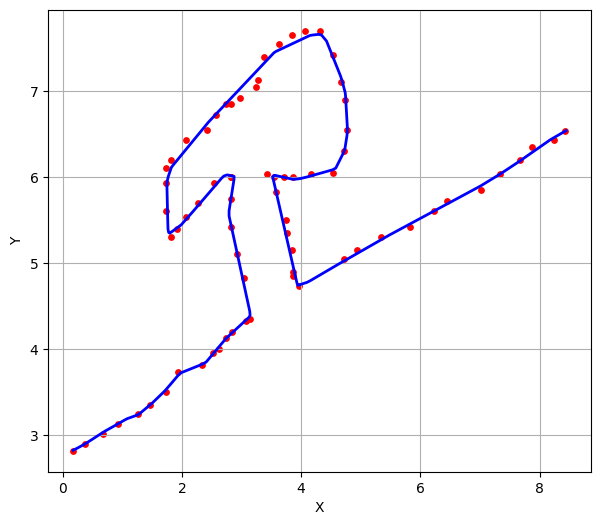

In [128]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 치킨 좌표
data = torch.tensor([
    [0.17, 2.82], [0.37, 2.90], [0.67, 3.02], [0.92, 3.13], [1.27, 3.25],
    [1.47, 3.35], [1.74, 3.50], [1.94, 3.73], [2.34, 3.82], [2.52, 3.95],
    [2.62, 4.00], [2.74, 4.13], [2.84, 4.20], [3.07, 4.33], [3.14, 4.35],
    [3.04, 4.83], [2.92, 5.10], [2.82, 5.42], [2.82, 5.75], [2.82, 6.00],
    [2.82, 6.00], [2.54, 5.93], [2.27, 5.70], [2.07, 5.53], [1.92, 5.40],
    [1.82, 5.30], [1.74, 5.60], [1.74, 5.93], [1.74, 6.10], [1.82, 6.20],
    [2.07, 6.43], [2.57, 6.72], [2.74, 6.85], [2.82, 6.85], [2.97, 6.92],
    [3.24, 7.05], [2.42, 6.55], [3.27, 7.13], [3.37, 7.40], [3.62, 7.55],
    [3.84, 7.65], [4.07, 7.70], [4.32, 7.70], [4.54, 7.42], [4.67, 7.10],
    [4.74, 6.90], [4.77, 6.55], [4.72, 6.30], [4.54, 6.05], [4.17, 6.03],
    [3.87, 6.00], [3.72, 6.00], [3.54, 6.00], [3.42, 6.03], [3.57, 5.83],
    [3.74, 5.50], [3.77, 5.35], [3.84, 5.15], [3.87, 4.90], [3.87, 4.85],
    [3.97, 4.73], [4.72, 5.05], [4.94, 5.15], [5.34, 5.30], [5.82, 5.42],
    [6.22, 5.60], [6.44, 5.72], [7.02, 5.85], [7.34, 6.03], [7.67, 6.20],
    [7.87, 6.35], [8.24, 6.43], [8.42, 6.53]
], dtype=torch.float32)

# 입력 = t, 출력 = (x, y)
t = torch.linspace(0, 1, len(data)).reshape(-1, 1)
X_target = data  # 출력 목표: (x, y)

# 모델 정의
model = nn.Sequential(
    nn.Linear(1, 128), # layer 0, 첫 입력은 1개 (t)
    nn.ReLU(),
    nn.Linear(128, 128), # Layer 1
    nn.ReLU(),
    nn.Linear(128, 128), # Layer 2
    nn.ReLU(),
    nn.Linear(128, 2) # Layer 3, 최종 출력은 2개 (x, y)
)

# 학습 설정
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# 학습
for epoch in range(15000):
    X_pred = model(t)
    loss = criterion(X_pred, X_target)

    optimizer.zero_grad() # 기울기 초기화
    loss.backward() #역전파
    optimizer.step() #기울기 업데이트

    if epoch % 1000 == 0:
        print(f"Epoch {epoch:5d} | Loss: {loss.item():.6f}")


# 예측 선 생성
with torch.no_grad():
  t_dense = torch.linspace(0, 1, 400).reshape(-1, 1)
  pred_curve = model(t_dense)

  # 시각화
  plt.figure(figsize=(7,6))
  plt.scatter(X_target[:,0], X_target[:,1], color='red', s=15)
  plt.plot(pred_curve[:,0], pred_curve[:,1], color='blue', linewidth=2)
  plt.xlabel("X")
  plt.ylabel("Y")
  plt.grid(True)
  print()

### 왜 회귀선으로 그림을 그렸나요?
- ReLU 같은 비선형 방정식의 중첩을 모델로 사용하면, 비선형 방정식들을 모사할수 있다는 것을 입증하기 위함입니다.

# 8. MNIST 데이터 셋 소개
- MNIST : Modified National Institute of Standards and Technology database
  - 한글 번역 : 수정된 미국 국립표준기술원 데이터베이스
- 그냥 손글씨 숫자 이미지 자료입니다.
  - 글자당 28 x 28 픽셀
  - 0 ~ 9 숫자
  - 검은색 배경에 밝은 색 글씨
- 데이터가 아니라 데이터 셋 입니다.
  - 데이터 셋 = 데이터 + 정답 값 (Label) 입니다.
  - MNIST 데이터 셋은, 손글씨 이미지랑, 어떤 숫자인지 정답이 함께 들어있습니다.


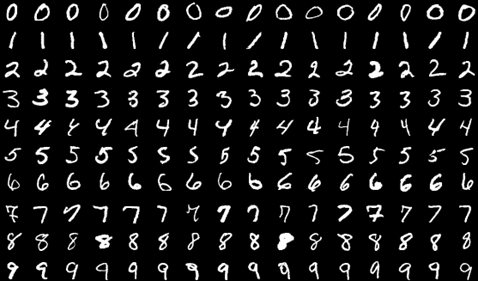

- 숫자 하나를 확대해보겠습니다.
  - 28 x 28 픽셀이니까 총 784 칸으로 구성된 이미지
  - 각 칸마다 명도값이 적혀있습니다. (0 ~ 255, 0 이면 검은색, 255는 흰색)

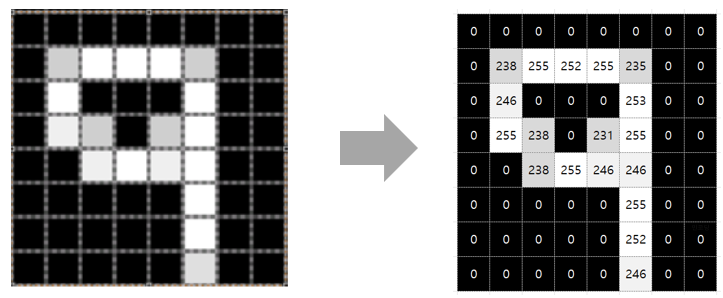

- 각 이미지는 28×28 크기의 흑백 이미지이며, 숫자 0부터 9까지 총 10개의 클래스로 구성 됩니다.
- 학습용 데이터: 60,000장
- 테스트용 데이터: 10,000장
- 이미지 크기: 28×28
- 색상 채널: 1채널(흑백)

#### MNIST 데이터 셋으로 뭘 할까요?
- 우리는 MNIST 데이터셋을 이용한 숫자 분류기를 만들어볼겁니다.
  - PyTorch의 Data Loader도 사용해볼겁니다.
    - 그리고 2개의 레이어로 구성된 MLP 모델을 만들겁니다.
- 이 실습을 위해 필요한 내용들을 하나씩 학습해보시죠.

먼저 가볍게 실습에 필요한 Pytorch 문법을 한번 더 체크해 보겠습니다.
텐서와 자주 사용하는 메서드 들 입니다.

In [130]:
import torch

# 스칼라 사용해 보기
x = torch.tensor(42)
print(x)
print(x.shape)


# shape으로 tensor의 size를 확인 할 수 있으며
# 데이터가 몇 차원으로, 그리고 각 차원마다 몇 개씩 들어 있는지 알려준다.
# (배열로 따지면 몇*몇 배열인지 확인이 가능하다)


# 벡터 만들어 보기
b = torch.tensor([1, 2, 3])
print(b)
print(b.shape)

# 행렬 만들어 보기
c = torch.tensor([[1, 2, 3], [3, 4, 5]])
print(c)
print(c.shape)

# 3차원 텐서 만들어 보기
d = c = torch.tensor([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])
print(d)
print(d.shape)


tensor(42)
torch.Size([])
tensor([1, 2, 3])
torch.Size([3])
tensor([[1, 2, 3],
        [3, 4, 5]])
torch.Size([2, 3])
tensor([[[1, 2],
         [3, 4]],

        [[5, 6],
         [7, 8]]])
torch.Size([2, 2, 2])


#### * 그 다음은 randn() 입니다.

randn은 값이 0을 중심으로 음수와 양수가 랜덤하게 섞여 나옵니다.
평균 0, 표준편차 1의 정규분포(Normal distribution) 난수(실수값)를 생성할때 사용합니다. 넘파이와 상당히 유사 합니다.

In [131]:
# randn은 값이 0을 중심으로 음수와 양수가 랜덤하게 섞여 나옴
# 평균 0, 표준편차 1의 정규분포(Normal distribution)기반으로 난수를 생성

import torch

# 난수 4개 1차원 텐서에 생성
x = torch.randn(4)
print(x)

# 난수 4개를 2차원 텐서(1행 4열)로 생성
x = torch.randn(1, 4)
print(x)

# (1, 3, 1, 2) 형태의 4차원 텐서 생성
x = torch.randn(1, 3, 1, 2)
print(x)

# 출력결과:

# tensor([[
#     [[-0.3,  0.7]],   # 채널 1
#     [[1.2, -0.5]],   # 채널 2
#     [[0.4,  2.1]]    # 채널 3
# ]])

tensor([ 0.5319, -0.4299,  0.3064, -1.1531])
tensor([[-1.5439,  0.9342, -0.3220,  1.5500]])
tensor([[[[-0.0754, -1.2322]],

         [[-0.7618,  0.0157]],

         [[-0.5963, -0.1018]]]])


#### * 그 다음은 squeeze() 입니다.
크기가 1인 모든 차원을 제거할때 사용합니다.

In [132]:
import torch

x = torch.randn(1, 3, 1, 2)

x = x.squeeze()

print(x)

# 예시
# tensor([[[[ 1.4844,  0.0485]],

#          [[ 0.7719,  1.6320]],

#          [[-0.2751, -0.3598]]]])

# 가

#  tensor([[ 1.4844,  0.0485],
#         [ 0.7719,  1.6320],
#         [-0.2751, -0.3598]])

# 가 되면서 4차원이 2차원으로 되면서 필요한 값만 남습니다.
# torch.Size([1, 3, 1, 2]) → torch.Size([3, 2]) 되는 것입니다.


tensor([[-0.5069, -0.5490],
        [-0.8462, -0.7180],
        [ 0.5319, -1.2827]])


#### * 그 다음은 unsqueeze() 입니다.


In [133]:
import torch

x = torch.randn(3, 3)
print(x)
print(x.shape)

x = x.unsqueeze(0) # 0번쨰 차원(shape텐서(배열)로따지면 0번 index)에 차원을 추가
print(x)
print(x.shape)

tensor([[-1.2354, -2.4697, -1.8346],
        [ 0.5562,  0.0691, -0.9628],
        [-1.7693,  0.5166, -0.2929]])
torch.Size([3, 3])
tensor([[[-1.2354, -2.4697, -1.8346],
         [ 0.5562,  0.0691, -0.9628],
         [-1.7693,  0.5166, -0.2929]]])
torch.Size([1, 3, 3])


#### * 그 다음은 torch.flatten() 입니다.
다차원 텐서를 평탄화할때 사용합니다.

In [134]:
import torch

x = torch.randn(2, 3, 2)
print(x)
print(x.shape)

y1 = torch.flatten(x)
print(y1.shape)
print(y1)
print("===========================================================")
y2 = torch.flatten(x, 1)  # start_dim=1을 쓰면
print(y2.shape)           # 0번 인덱스(배치 차원)는 보존, 나머지는 평탄화
print(y2)



tensor([[[ 1.4894, -0.0233],
         [ 0.5012,  2.2473],
         [ 1.0350,  0.5524]],

        [[ 0.3327, -0.6105],
         [-0.0145, -0.3281],
         [-1.1721, -1.1189]]])
torch.Size([2, 3, 2])
torch.Size([12])
tensor([ 1.4894, -0.0233,  0.5012,  2.2473,  1.0350,  0.5524,  0.3327, -0.6105,
        -0.0145, -0.3281, -1.1721, -1.1189])
torch.Size([2, 6])
tensor([[ 1.4894, -0.0233,  0.5012,  2.2473,  1.0350,  0.5524],
        [ 0.3327, -0.6105, -0.0145, -0.3281, -1.1721, -1.1189]])


#### * 그 다음은 size 입니다.

In [135]:
import torch

x = torch.tensor([1, 2, 3])
print(x.size())  # torch.Size([3])
print(x.size()[0])  # 3
print(x.size(0))  # 3


torch.Size([3])
3
3


* 그 다음은 Max 입니다.

In [136]:
import torch

outputs = torch.tensor([[0.1, 0.8, 0.1],
                        [0.3, 0.2, 0.5]])


values, indices = torch.max(outputs, 0)
print(values)
print(indices)

values, indices = torch.max(outputs, 1)
print(values)
print(indices)


# 디멘션(dim)을 넣어준다.

# dim=0 → 각 행의 같은 열(column, 즉 클래스별로) 최댓값을 찾는다.
# tensor([0.3, 0.8, 0.5])
# tensor([1, 0, 1]) → Max값의 인덱스

# dim=1 → 각 열의 같은 행(row, 즉 각 샘플 안에서) 최댓값을 찾는다
# tensor([0.8, 0.5])  ← 예를들면 각 샘플의 최대 점수를 얻고
# tensor([1, 2])      ← 예측 클래스 (1번, 2번)

tensor([0.3000, 0.8000, 0.5000])
tensor([1, 0, 1])
tensor([0.8000, 0.5000])
tensor([1, 2])


자, 이제 준비가 되었습니다. 먼저 device 설정을 해 줄것인데요.
Pytorch로 연산을 할 때 GPU를 사용하도록 설정을 해 주겠습니다.
그 다음 Pytorch에서 제공해주는 MNIST 데이터를  다운받기 부터 해 보겠습니다.


In [137]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'사용 장치: {device}')

사용 장치: cuda


In [138]:
from torchvision import datasets, transforms #이미지 관련 진행할 때 
from torch.utils.data import DataLoader

# 데이터 전처리 설정
transform = transforms.Compose([transforms.ToTensor()])

# MNIST 데이터셋 다운로드
train_datasets=datasets.MNIST(root='./data',
               train=True,transform=transform,download=True)
test_datasets=datasets.MNIST(root='./data',
               train=False,transform=transform,download=True)

# 데이터 로더 설정
train_loader = DataLoader(train_datasets, batch_size=32, shuffle=True)
test_loader = DataLoader(test_datasets, batch_size=32, shuffle=False)

* torchvision은 Pytorch에서 제공해주는 이미지 셋을 다운받거나 이미지 전처리 기능할 사용할때 자주 사용하는 라이브러리 입니다. 그 중에서
* datasets는 MNIST 데이터 다운받을때 사용하는 라이브 러리 입니다.
    * train=True 면 이미지 6만장 False면 1만장이 들어옵니다.
    * 이미지를 다운 받으면 Pytorch가 학습용/테스트용을 알아서 구분해서 다운받아 집니다.
* transforms는 데이터를 전처리 하는 라이브러리, 여기서는 다운받은 이미지를 텐서로 변환할때 사용 합니다.
* DataLoader는 여러개의 이미지를 하나의 batch로 묶을때 사용하는데 자세히 살펴 보겠습니다.

#### PyTorch의 DataLoader 이해하기

- 딥러닝을 다룰 때 Data Loader는 앞으로 계속 쓰게 될 것이니, 조금 자세히 이해를 하도록 하겠습니다.
- 데이터셋을 랜덤하게 섞어서 학습시키면 학습이 더 잘됩니다.
  - 예시
    - 고등어만 100 만 마리 학습시키면, 모델이 특징을 잘못 잡습니다.
    - 고등어랑 오징어랑 섞어가면서 학습시면, 모델이 비교하면서 특징을 더 잘잡습니다.
    - 역시 수학적 증명은 생략 ^^
<br/>

#### PyTorch DataLoader, 꼭 알아두기

* PyTorch의 DataLoader는 앞으로 딥러닝을 다루면서 계속 쓰이게 될 중요한 도구입니다.
  쉽게 예를들면, 데이터를 조금씩 나눠서 모델에게 먹이를 주는 도우미 역할을 합니다..

* DataLoader의 원래 목적은
  데이터가 너무 커서 한 번에 전부 메모리에 올리기 힘들 때,  **조금씩 (batch 단위로)** 나눠서 읽어오는 겁니다. 그래서 메모리도 아끼고, 학습도 효율적으로 할 수 있게 도와주는 목적도 있습니다..

* 또한, DataLoader를 사용할때 학습시킬 데이터를 랜덤으로 섞을지 말지 선택하는 옵션도 같이 적어 주곤 합니다.`shuffle=False` 옵션이 학습시 사용될 데이터를 랜덤하게 섞는 옵션이라는 것도 기억해 주세요.

- 따라서 DataLoader를 사용하는 이유를 뭍는다면
  - 랜덤하게 훈련용 데이터를 준비할 수 있으며
  - 엄청나게 거대한 데이터 전체를 한꺼번에 읽지 않고, 조금씩 읽어올 수 있게 도와주기 때문이라고 할 수 있습니다.

  

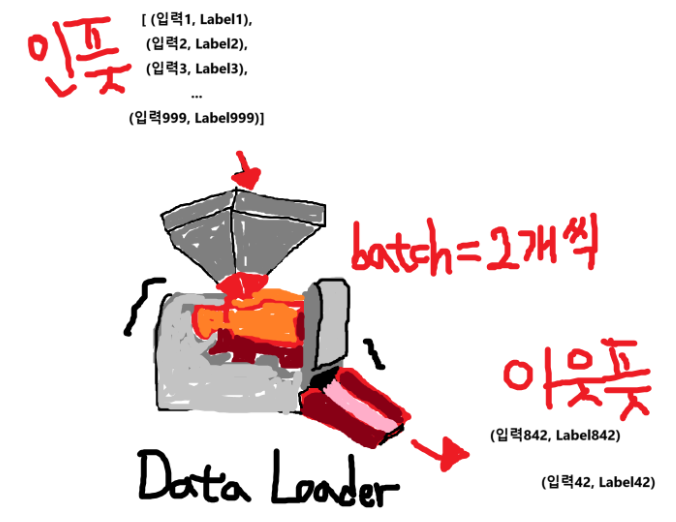

### PyTorch의 DataLoader가 원하는 자료 형태
- DataLoader가 원하는 입력 형태가 있습니다.
- (입력데이터, Label) 형태로 된 Tuple들의 List 형태를 입력으로 주면 됩니다.

`input = ["TigerStar", "Mino", "J-Dragon"]` 입력값(input) <br>
`label = ["범성", "민호", "자룡"]` 출력값(label)

`print(list(zip(input, label)))`

# 데이터 로더 설정
- `train_loader = DataLoader(train_datasets, batch_size=32, shuffle=True)`
- `test_loader = DataLoader(test_datasets, batch_size=32, shuffle=False)`
    - train_datasets에서 로드를 하는데 32개의 샘플을 하나의 배치로 로딩하고
    - 데이터셋(예: MNIST 전체 60,000장 이미지)을 한 번에 모두 처리하지 않고,
    - 한 번에 32개씩 나누어서(=batch) 모델에 입력해서 학습/테스트하겠다는 뜻
    - (트레이닝을 더 잘하기 위함)
    - shuffle을 통해서 데이터를 섞어서 불러오겠다는 뜻 (학습 효율을 위해)
    - 이미지 32장을 한 묶음으로 모아서 처리한다는 뜻

#### MNIST 데이터 출력해보기 (Matplotlib 사용)

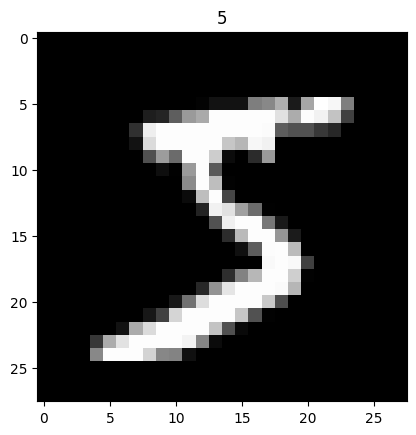

In [139]:
import matplotlib.pyplot as plt

# 다운받은 MNIST 샘플 이미지 데이터 출력해보기
sample_data = train_datasets[0] #첫 번째 샘플 출력
#print(sample_data)
sample_image, sample_label = sample_data #입력값, 해당 레이블

plt.imshow(sample_image.squeeze(), cmap='gray')

plt.title(sample_label)

plt.show()

* 앞전에 다운로드된 데이터 중 첫번째 샘플을 꺼내 봅니다. (image_tensor, label) 튜플 형태 반환
* sample_image의 형태를 봅니다.
  * sample_image.shape  `torch.Size([1, 28, 28])`
  * 1: 채널수(channel)(MNIST는 흑백을 1채널, 컬러는 3채널 이라고 합니다.)  /  28, 28은 각각 이미지 높이와 너비를 뜻합니다.

* imshow()는 이미지를 시각화 하는 함수입니다.
* .squeeze() : 이미지 1장 보여주는데 필요 없는 값 제거하고
* cmap='gray' 의 의미는 colormap = 'gray' 라는 뜻으로 이미지를 흑백 이미지로 시각화 하겠다는 의미 입니다.


In [ ]:
#### 자 이제 신경망 모델을 구축 해 봅시다.

In [140]:
import torch
import torch.nn as nn

class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()   # nn모듈의 생성자 함수 상속
        self.fc1 = nn.Linear(28*28, 128)   # fc1,fc2라고 하는 두개의 레이어 정의해주기(은닉층에 들어갈 수)
        self.fc2 = nn.Linear(128, 10)      # fully connected Layer 를 줄여서 fc라는 공식 약어를 사용 합니다.
                                           # 숫자가 총 10개라서 10으로 입력


    def forward(self, x):
        x = torch.flatten(x, 1) # nn.Linear가 1차원으로 입력 받아서 2차원을 1차원으로 변경
        x = self.fc1(x) 
        x = nn.functional.relu(x) # 비선형 그래프로 바뀐 값을 2번에 넣어준다
        x = self.fc2(x) # 각 숫자에 대한 확률을 출력할거라서 relu 안함
        return x

- nn.Linear는 신경망의 "층(layer)"을 정의하는 클래스 입니다.
  - 입력 차원과 출력 차원을 지정해서, 입력 데이터를 선형변환(가중치·편향 적용) 합니다.
  - 예: 28*28 픽셀(=784차원 입력)을 받아 128차원 벡터로 변환하는 레이어.
    - 즉, 784개의 원소를 128개의 특징 벡터(feature vector)로 압축/가공하는 과정이라는 뜻입니다.
    - 여기서 128은 하이퍼파라미터로, 보통 2의 제곱수(128, 256 등)를 많이 사용합니다.

- forward (순전파)
  - 신경망의 nn.Linear(완전연결층)는 2차원 입력 [배치크기, 특징차원]만 받습니다.
  - 따라서 CNN이나 이미지 데이터를 MLP에 넣으려면 꼭 flatten(평탄화 작업)이 필요합니다.
    - 예를들어,
    - x.shape = [32, 1, 28, 28] 라고 할때,
      - 32 = 배치 크기(이미지 32장)
      - 1  = 채널 수(흑백 이미지)
      - 28×28 = 가로×세로 픽셀 수 를 의미 합니다.
    - 이떄, `x = torch.flatten(x, 1)`을 하면 `x.shape = [32, 784]`가 됩니다.
    - 즉, 32 = 배치 크기 그대로 유지하면서 784 = 1×28×28 픽셀을 1차원 벡터로 펼친 값으로 변환이 되는 것입니다.
  - 이후 fc1 레이어에 넣어 128차원 벡터로 변환하고,
  - ReLU 활성화 함수를 거쳐 비선형성을 추가한 뒤,
  - fc2 레이어에 넣어 가중치(W), 편향(b)를 학습해 최종 10개 분류 클래스에 대한 출력을 만듭니다.      


#### 인공신경망 모델을 학습시켜 보자.
자 우리가 모델도 정의해 놓았고 그리고 모델에 입력값으로 넣을 이미지도 준비가 되었습니다.
모델을 학습시키는 과정을 다시한번 확인해 봅니다.

In [ ]:
입력 → 순전파 → 예측값 → 손실 계산 → 역전파 → 최적화(가중치 업데이트)
   ↑                                                    ↓
   └────── gradient 초기화 (zero_grad) ──────────────────ㅡ┘
                     ↑
                     └──── 학습 반복 ────┘

먼저 순전파 입니다.
```
입력 (28×28 픽셀)
   ↓
입력층 (784 뉴런에 가중치·편향 적용)
   ↓
은닉층 1 → ReLU (활성화함수 적용)
   ↓
은닉층 2 → ReLU 적용 안함 (마지막 은닉층의 출력값이 10개 클래스의 점수가 될것이라서 활성화 함수 적용안합니다)
   ↓
출력층 (예: 10개 클래스 점수)


```

그다음 손실함수 입니다.
```
손실계산
- 손실 측정을 위한 corss-entropy (크로스엔트로피 : 다항, 내부에 softmax함수 들어있음) 손실함수를 사용 할 것입니다.
- 마지막 출력층이 softmax로 0~9 (10개 클래스)에 대해 확률값을 출력할 때 대표적으로 쓰는 손실 함수입니다.
- softmax는 probability 분포로 모델이 **어떤 클래스일 확률이 가장 높은지** 알려줍니다.    
- BCE 함수는 이항 분류, sigmoid 함수 내장
```

그 다음 역전파 입니다.
  - 역전파를 통해서 손실함수값 Loss를 가지고 기울기를 구할 것입니다.

그 다음 가중치 업테이트 (Optimization) 입니다. SGD를 이용해서 가중치와 편향값을 조금씩 수정을 할 것입니다.

그 다음은 잊으면 안되죠? 기울기 초기화 입니다. `optimizer.zero_grad()` 를 통해서 기울기 초기화 합니다.
```


이렇게 데이터의 한 batch로(묶음) 학습을 하는 것을 1 step 이라 하며

준비된 모든 데이터를 이용해서 여러번의 step을 마치는 것을 1 epoch 이라고 합니다.

예를들어 MNIST로 부터 모델훈련에 사용할 이미지를 다운받으면 60000장이 다운로드가 되는데요.

한번에 60000장을 한번 학습하는것 보다 60000만장을 32장을 하나의 묶음으로 1875번 반복해서 학습을 하면서 매개변수를 조정해 나가는 것입니다.

In [141]:

import torch.optim as optim  #최적화를 위한 라이브러리

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

net = SimpleNN().to(device) #.to(device) : gpu환경에서 실행되도록(매우 중요)

net.train()  # 학습모드 켜기

optimizer = optim.SGD(net.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

for epoch in range(10):
    for i, data in enumerate(train_loader):
        inputs, labels = data #input에 픽셀 값, label에 정답

        inputs = inputs.to(device)   # GPU 연산을 위해 데이터도 같이 GPU로 보냅니다.
        labels = labels.to(device)   # 모델은 GPU에 있는데 학습시킬데이터는 CPU에 있으면 연산이 불가능 합니다. (중요)

        # 기울기 초기화
        optimizer.zero_grad()

        # 순전파
        outputs = net(inputs)

        # 손실계산
        loss = criterion(outputs, labels)

        # 역전파
        loss.backward()

        # 옵티마이저
        optimizer.step()
    print(f'Epoch: {epoch}, Loss:{loss.item()}')

#torch.save(net, 'model.pt') 학습 완료된 모델을 파일로 저장 (모델구조 + 가중치 전체를 통째로 저장하는방식)
torch.save(net.state_dict(), 'model.pt') #가중치만 저장하는 방식

Epoch: 0, Loss:0.25873807072639465
Epoch: 1, Loss:0.5817442536354065
Epoch: 2, Loss:0.1690426766872406
Epoch: 3, Loss:0.23713520169258118
Epoch: 4, Loss:0.1590198427438736
Epoch: 5, Loss:0.18525193631649017
Epoch: 6, Loss:0.11817982792854309
Epoch: 7, Loss:0.1984737366437912
Epoch: 8, Loss:0.2207382768392563
Epoch: 9, Loss:0.10078941285610199


- 에폭을 많이 돌릴수록 train loss는 일반적으로 계속 감소합니다.

- 하지만 loss 감소폭이 매우 작아지는 와중에, validation 데어터로 검증시 loss가 증가하거나 불안정 하다면

- 과적합을 방지하기 위해 Early stopping을 적용할 수 있습니다.

- 단, 주의할 점은 Early stopping은 반드시 훈련 데이터가 아닌 검증 데이터 기준으로 "수행"해야 합니다.
  - 훈련 데이터의 loss는 에폭이 증가할수록 계속 감소하는 경향이 있습니다.
  - 따라서 train loss만으로는 과적합 여부를 판단하기 어렵습니다.
    

#### 검증을 한번 해볼까요?

In [145]:
import torch

# net = torch.load('model.pt', weights_only=False)
net = SimpleNN().to(device) #gpu로 진행
net.load_state_dict(torch.load('model.pt', map_location=device)) #gpu에서 적용할 때 :map_location=device

net.eval() # Dropout 기능끄고, BatchNorm 고정(검증모드)

correct = 0
total = 0

with torch.no_grad(): # 이 안에서는 미분 계산이 필요 없으니 autograd 추적을 꺼줘
    for data in test_loader:
        images, labels = data

        images = images.to(device)
        labels = labels.to(device)

        outputs = net(images)

        _, predicted = torch.max(outputs, 1)  # 확률과,  확률이 가장높은값의 인덱스가 저장됨

        total += labels.size(0) # .size(0)을 사용하면 배치의 데이터 개수 확인가능 (총 이미지의 개수를 다 더해서)

        correct += ((predicted == labels).sum().item()) # (true 1 or false 0)의 개수를 더한 후 .item을로 정수값으로 변환

accuracy = 100*correct/total
print(f'accuracy:{accuracy}')


accuracy:94.62


여기서 살펴 볼 내용은 바로 `net.eval()` 이다.

net.eval은 모델 평가시
net.tain은 모델 학습시 호출해 주는 매서드 입니다.
이 둘의 차이점은 다음과 같습니다.

- net.train()  : Dropout 을 켜고, BatchNorm 학습합니다.
- net.eval()   : Dropout 을 끄고, BatchNorm 고정합니다.



여기서 Dropout 그리고 BatchNorm이 무엇일까요?
Dropout은 학습할 때 일부 뉴런을(레이어의 출력값) 랜덤으로 꺼서 과적합을 막는 기술입니다. 모델이 너무 똑똑해 지면 훈련데이터만 달달 외우는 것을
방지하기 위함 입니다. 예를들면 fc1의 출력이 `[x1, x2, x3, x4, x5, ...]` 이라면, Dropout을 적용시 `[x1, 0, x3, 0, x5, ...]` 이렇게 일부 출력값을 0으로 만드는 기술입니다.

[첫번째와 두번째 레이어 사이에 넣음 -> 과적합 방지]

그리고 BatchNorm은 레이어의 출력값을 정규화(평균0 분산1로 스케일링) 해서 학습을 안정화 시키는 것을 말합니다.

[은닉층 사이에 BatchNorm을 넣어서 정규화 시킨다 -> 학습을 더 잘 시키기 위해서]

물론, tain() 또는 eval() 메서드를 썻다고 자동 적용되는것은 아니고, Dropout 그리고 BatchNorm을 작동시킬 코드를 직접 추가해야 합니다.

# 수정전
```
import torch
import torch.nn as nn

class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()   # nn모듈의 생성자 함수 상속
        self.fc1 = nn.Linear(28*28, 128)   # fc1,fc2라고 하는 두개의 레이어 정의해주기
        self.fc2 = nn.Linear(128, 10)      # fully connected Layer 를 줄여서 fc라는 공식 약어를 사용 합니다.

        
    def forward(self, x):
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = nn.functional.relu(x)
        x = self.fc2(x)
        return x  
```

# 수정후
```
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.bn1 = nn.BatchNorm1d(128)      # 1차원 벡터 1d 2차원 이미지 2d(출력값 정규화)
        self.dropout = nn.Dropout(0.5)      # 뉴런을 끌 확률이 50%로 셋팅
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = self.bn1(x)                     # batchnorm - 학습안정화
        x = nn.functional.relu(x)
        x = self.dropout(x)                 # dropout - 과적합방지
        x = self.fc2(x)
        return x
```

#### 이렇게 적용시킬 수 있습니다. 오늘도 수고 많으셨습니다.
# 끝으로
### Easy 자료 (강사님 자료)
- AI를 처음 공부하는 분들을 위해 만들어져있습니다.
- 내용을 모두 이해해야합니다! **강사님의 도움을 적극적으로 받아주세요.**

### 실습 / 과제 자료 (업스테이지 자료)
- AI를 공부해본 경험자 위주로 만들어져있습니다.
- 퍼즐조각을 모은다는 생각으로 공부해주세요!. **GPT의 도움을 적극적으로 받아주세요.**

### 교수님 강의
- 국내 최고의 AI 교수님들의 강의가 시작됩니다.
- 최대한 내용을 이해해봅시다.